## 5.1 사후 예측 점검


In [25]:
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

In [26]:
# az.style.use("arviz-grayscale")
from cycler import cycler
default_cycler = cycler(color=["#000000", "#6a6a6a", "#bebebe", "#2a2eec"])
plt.rc("axes", prop_cycle=default_cycler)
plt.rc("figure", dpi=300)
np.random.seed(123)

array([-1.081, -0.888, -0.623, -0.48 , -0.505, -0.345,  0.052,  0.061,
        0.215,  0.395,  0.643,  0.871,  0.776,  0.833,  1.224,  1.3  ,
        1.563,  1.669,  1.967,  1.95 ,  2.03 ,  2.284,  2.534,  2.531,
        2.765,  2.913,  3.168,  3.119,  3.385,  3.488,  3.538,  3.9  ,
        3.97 ])

array([ 9.357,  8.322,  8.745,  7.346,  7.028,  4.032,  1.49 ,  3.265,
        4.525,  3.339,  2.045, -1.336,  1.264, -0.813, -0.335,  0.152,
       -1.797, -4.772, -3.043, -5.293, -4.401, -5.294, -2.912, -3.68 ,
       -3.975, -7.202, -4.317, -7.854, -5.167, -5.135, -6.754, -6.662,
       -6.08 ])

array([[-1.0810000e+00, -8.8800000e-01, -6.2300000e-01, -4.8000000e-01,
        -5.0500000e-01, -3.4500000e-01,  5.2000000e-02,  6.1000000e-02,
         2.1500000e-01,  3.9500000e-01,  6.4300000e-01,  8.7100000e-01,
         7.7600000e-01,  8.3300000e-01,  1.2240000e+00,  1.3000000e+00,
         1.5630000e+00,  1.6690000e+00,  1.9670000e+00,  1.9500000e+00,
         2.0300000e+00,  2.2840000e+00,  2.5340000e+00,  2.5310000e+00,
         2.7650000e+00,  2.9130000e+00,  3.1680000e+00,  3.1190000e+00,
         3.3850000e+00,  3.4880000e+00,  3.5380000e+00,  3.9000000e+00,
         3.9700000e+00],
       [ 1.1685610e+00,  7.8854400e-01,  3.8812900e-01,  2.3040000e-01,
         2.5502500e-01,  1.1902500e-01,  2.7040000e-03,  3.7210000e-03,
         4.6225000e-02,  1.5602500e-01,  4.1344900e-01,  7.5864100e-01,
         6.0217600e-01,  6.9388900e-01,  1.4981760e+00,  1.6900000e+00,
         2.4429690e+00,  2.7855610e+00,  3.8690890e+00,  3.8025000e+00,
         4.1209000e+00,  5.2166560e+00,

array([[-1.72414181, -1.5947931 , -1.41718994, -1.32135125, -1.33810627,
        -1.23087417, -0.96480453, -0.95877273, -0.85556184, -0.73492573,
        -0.56871598, -0.41591024, -0.4795793 , -0.44137787, -0.17932943,
        -0.12839419,  0.04786857,  0.11890983,  0.31862961,  0.3072362 ,
         0.36085225,  0.5310832 ,  0.69863335,  0.69662275,  0.85344969,
         0.95263938,  1.12354053,  1.0907007 ,  1.26897406,  1.33800472,
         1.37151475,  1.61412737,  1.66104141],
       [-0.6811725 , -0.76003053, -0.84312138, -0.87585202, -0.87074204,
        -0.89896365, -0.92310164, -0.9228906 , -0.91407052, -0.89128571,
        -0.83786718, -0.76623575, -0.7987041 , -0.77967256, -0.61277348,
        -0.57296772, -0.41671773, -0.34562583, -0.12078093, -0.13459894,
        -0.06852717,  0.15885519,  0.40880321,  0.40565007,  0.66281204,
         0.83719337,  1.15897266,  1.09504594,  1.45405472,  1.6009563 ,
         1.67385522,  2.23259249,  2.34691077]])

array([ 2.0029501 ,  1.79855156,  1.88208835,  1.60580472,  1.54300401,
        0.95133442,  0.44932371,  0.79986227,  1.04869527,  0.81447627,
        0.55892872, -0.10877318,  0.40469175, -0.00548773,  0.08891082,
        0.18508675, -0.19981446, -0.78733683, -0.44588265, -0.89022731,
       -0.71406934, -0.89042479, -0.42001192, -0.57168156, -0.62994008,
       -1.26722906, -0.69748047, -1.39599026, -0.86534401, -0.85902444,
       -1.1787551 , -1.16058634, -1.04564919])

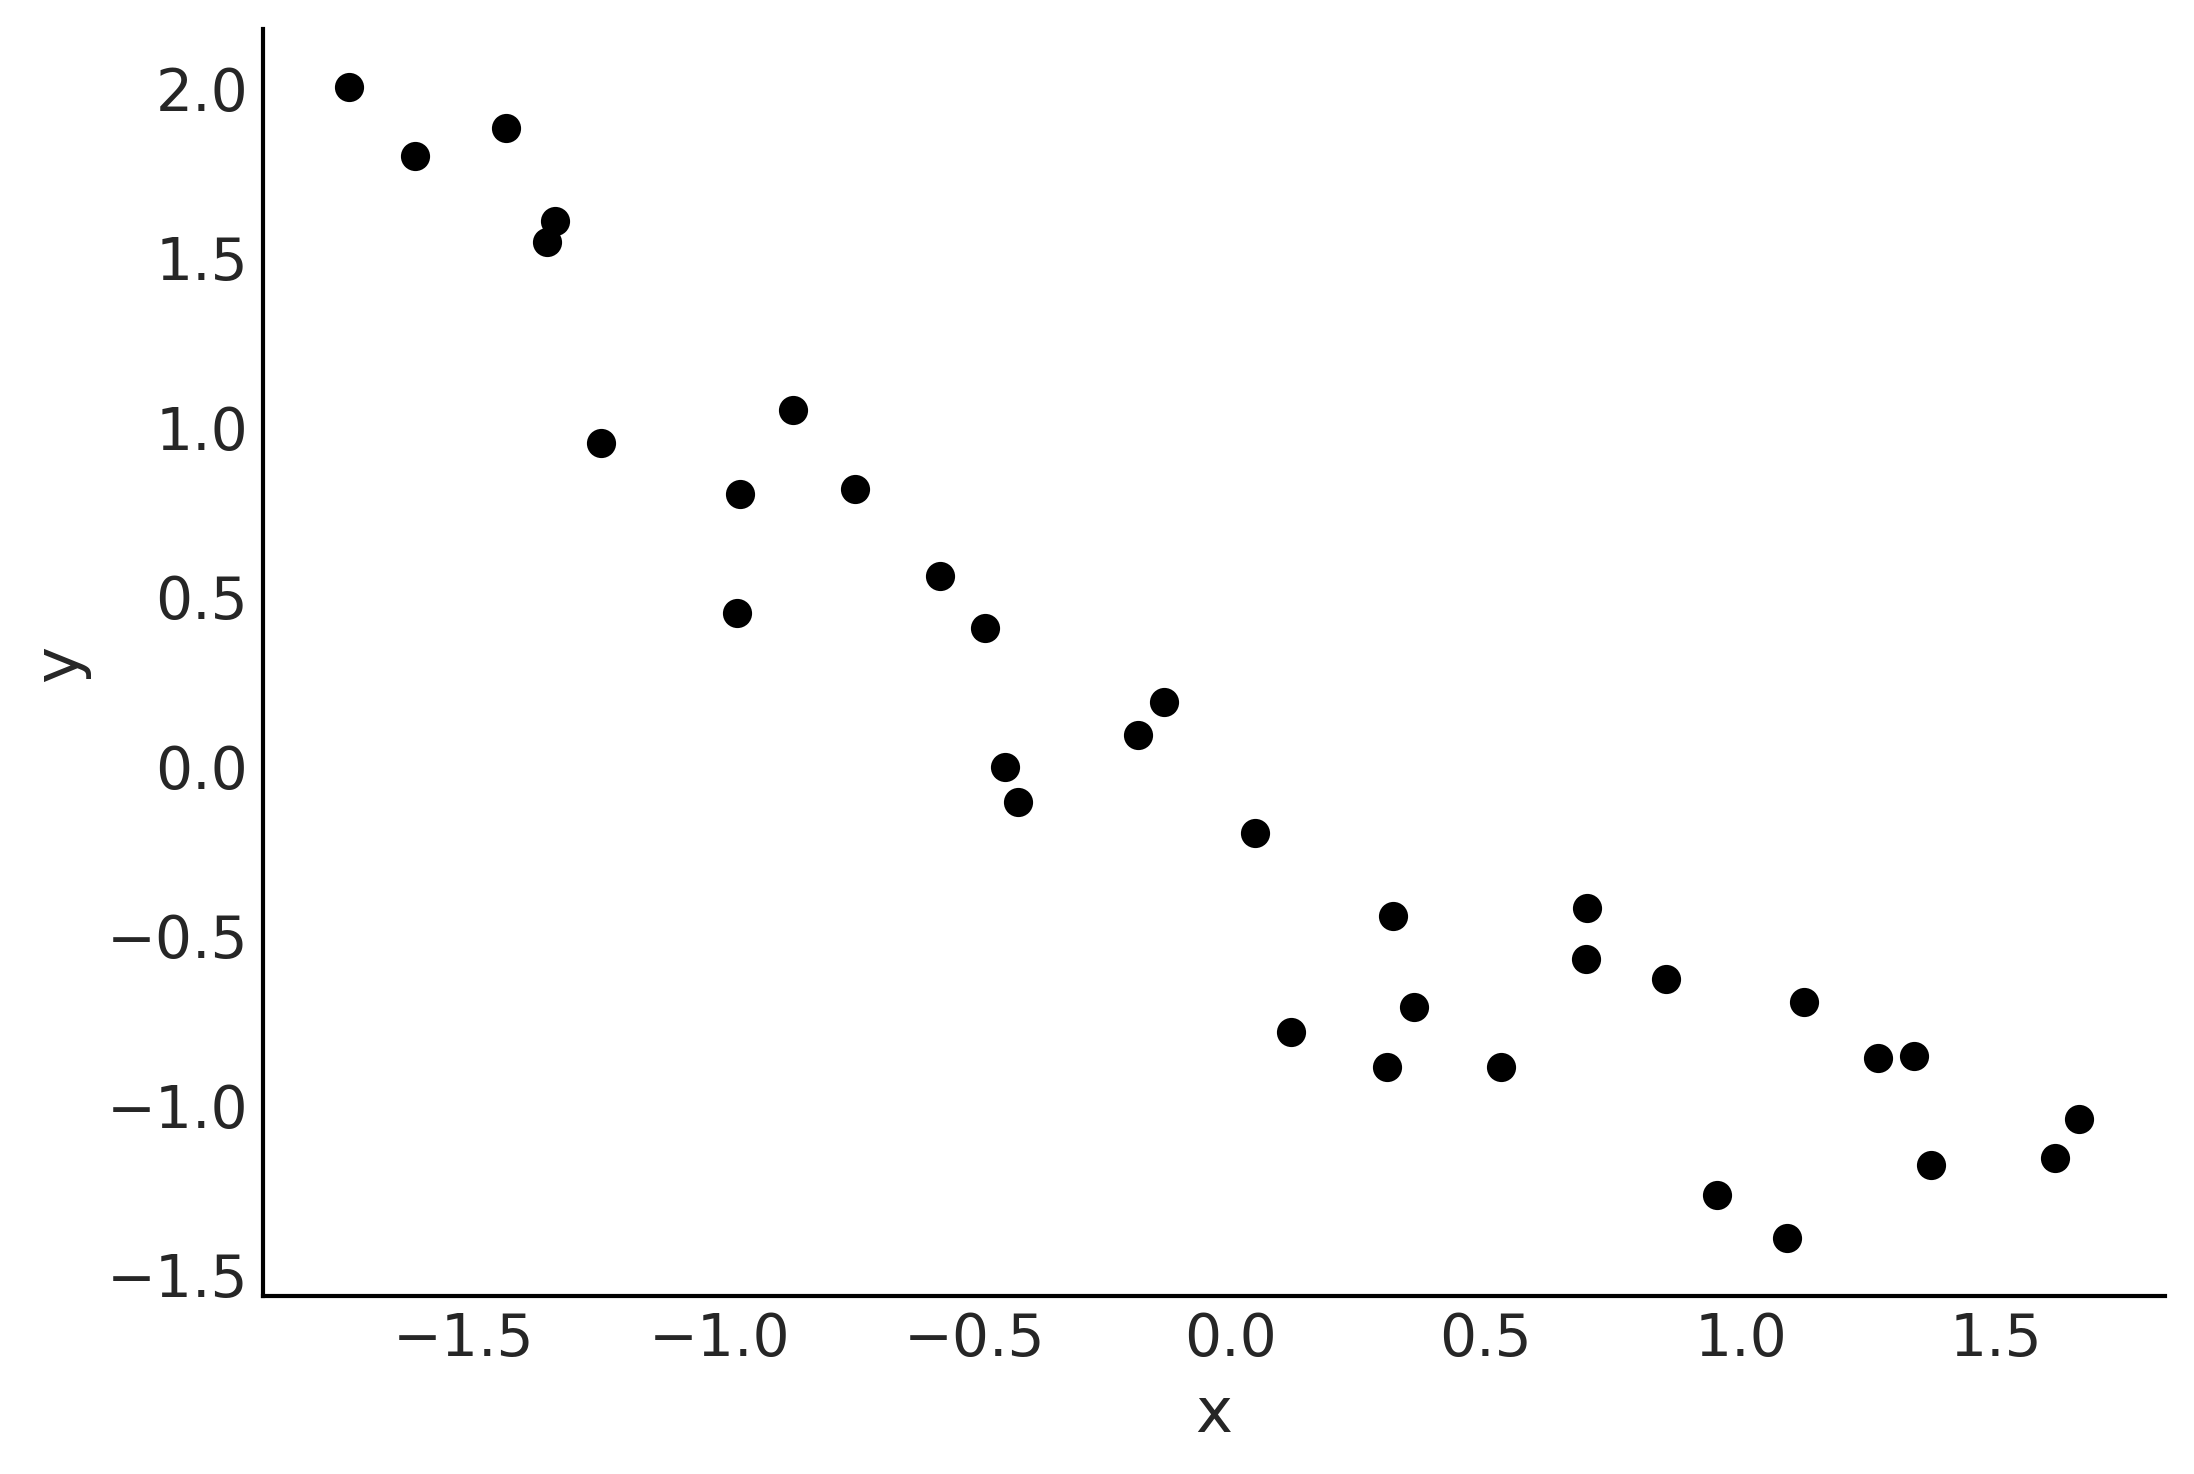

In [27]:
dummy_data = np.loadtxt("data/dummy.csv")
x = dummy_data[:, 0]
y = dummy_data[:, 1]

display(x, y)

order = 2
x_p = np.vstack([x**i for i in range(1, order + 1)])
display(x_p)

x_c = (x_p - x_p.mean(axis=1, keepdims=True)) / x_p.std(axis=1, keepdims=True)
y_c = (y - y.mean()) / y.std()

display(x_c, y_c)

plt.scatter(x_c[0], y_c)
plt.xlabel("x")
plt.ylabel("y");

In [28]:
with pm.Model() as model_l:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", 5)

    mu = alpha + beta * x_c[0]

    y_pred = pm.Normal("y_pred", mu=mu, sigma=sigma, observed=y_c)

    idata_l = pm.sample(2000, idata_kwargs={"log_likelihood": True})
    idata_l.extend(pm.sample_posterior_predictive(idata_l))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.
Sampling: [y_pred]


In [29]:
idata_l

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [30]:
with pm.Model() as model_q:
    alpha = pm.Normal('alpha', mu=0, sigma=1)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=order)
    sigma = pm.HalfNormal("sigma", 5)
    
    mu = alpha + pm.math.dot(beta, x_c)

    y_pred = pm.Normal("y_pred", mu=mu, sigma=sigma, observed=y_c)

    idata_q = pm.sample(2000, idata_kwargs={"log_likelihood": True})
    idata_q.extend(pm.sample_posterior_predictive(idata_q))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.
Sampling: [y_pred]


In [31]:
idata_q

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [32]:
x_new = np.linspace(x_c[0].min(), x_c[0].max(), 100)
display(x_new)

posterior_l = az.extract(idata_l)
posterior_q = az.extract(idata_q)
display(posterior_l, posterior_q)


array([-1.72414181, -1.68994804, -1.65575427, -1.6215605 , -1.58736673,
       -1.55317296, -1.51897919, -1.48478542, -1.45059165, -1.41639788,
       -1.38220411, -1.34801034, -1.31381657, -1.2796228 , -1.24542903,
       -1.21123526, -1.17704149, -1.14284772, -1.10865395, -1.07446018,
       -1.04026641, -1.00607264, -0.97187887, -0.9376851 , -0.90349133,
       -0.86929756, -0.83510379, -0.80091002, -0.76671625, -0.73252248,
       -0.69832871, -0.66413494, -0.62994117, -0.5957474 , -0.56155363,
       -0.52735986, -0.49316609, -0.45897232, -0.42477855, -0.39058478,
       -0.35639101, -0.32219724, -0.28800348, -0.25380971, -0.21961594,
       -0.18542217, -0.1512284 , -0.11703463, -0.08284086, -0.04864709,
       -0.01445332,  0.01974045,  0.05393422,  0.08812799,  0.12232176,
        0.15651553,  0.1907093 ,  0.22490307,  0.25909684,  0.29329061,
        0.32748438,  0.36167815,  0.39587192,  0.43006569,  0.46425946,
        0.49845323,  0.532647  ,  0.56684077,  0.60103454,  0.63

<xarray.Dataset>
Dimensions:  (sample: 8000)
Coordinates:
  * sample   (sample) object MultiIndex
  * chain    (sample) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 0 1 2 3 4 5 6 ... 1993 1994 1995 1996 1997 1998 1999
Data variables:
    alpha    (sample) float64 -0.127 0.1048 0.09244 ... 0.05014 -0.08058 0.07963
    beta     (sample) float64 -1.065 -0.8501 -0.9179 ... -1.005 -0.8892 -0.9952
    sigma    (sample) float64 0.3861 0.3706 0.4266 ... 0.3041 0.3819 0.3253
Attributes:
    created_at:                 2025-04-21T08:31:24.027291
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              2.8258254528045654
    tuning_steps:               1000

<xarray.Dataset>
Dimensions:     (sample: 8000, beta_dim_0: 2)
Coordinates:
  * beta_dim_0  (beta_dim_0) int64 0 1
  * sample      (sample) object MultiIndex
  * chain       (sample) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw        (sample) int64 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
Data variables:
    alpha       (sample) float64 0.04484 0.01174 0.02689 ... -0.02923 -0.05596
    beta        (beta_dim_0, sample) float64 -1.561 -1.534 ... 0.4564 0.5252
    sigma       (sample) float64 0.2352 0.2457 0.2562 ... 0.2557 0.2615 0.2486
Attributes:
    created_at:                 2025-04-21T08:31:37.652668
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              5.730098485946655
    tuning_steps:               1000

In [33]:
alpha_l_post = posterior_l['alpha'].mean().item()
beta_l_post = posterior_l['beta'].mean().item()
y_l_post = alpha_l_post + beta_l_post * x_new

In [34]:
alpha_q_post = posterior_q['alpha'].mean().item()
beta_q_post = posterior_q['beta'].mean('sample')
idx = np.argsort(x_c[0])
y_q_post = alpha_q_post + np.dot(beta_q_post, x_c)

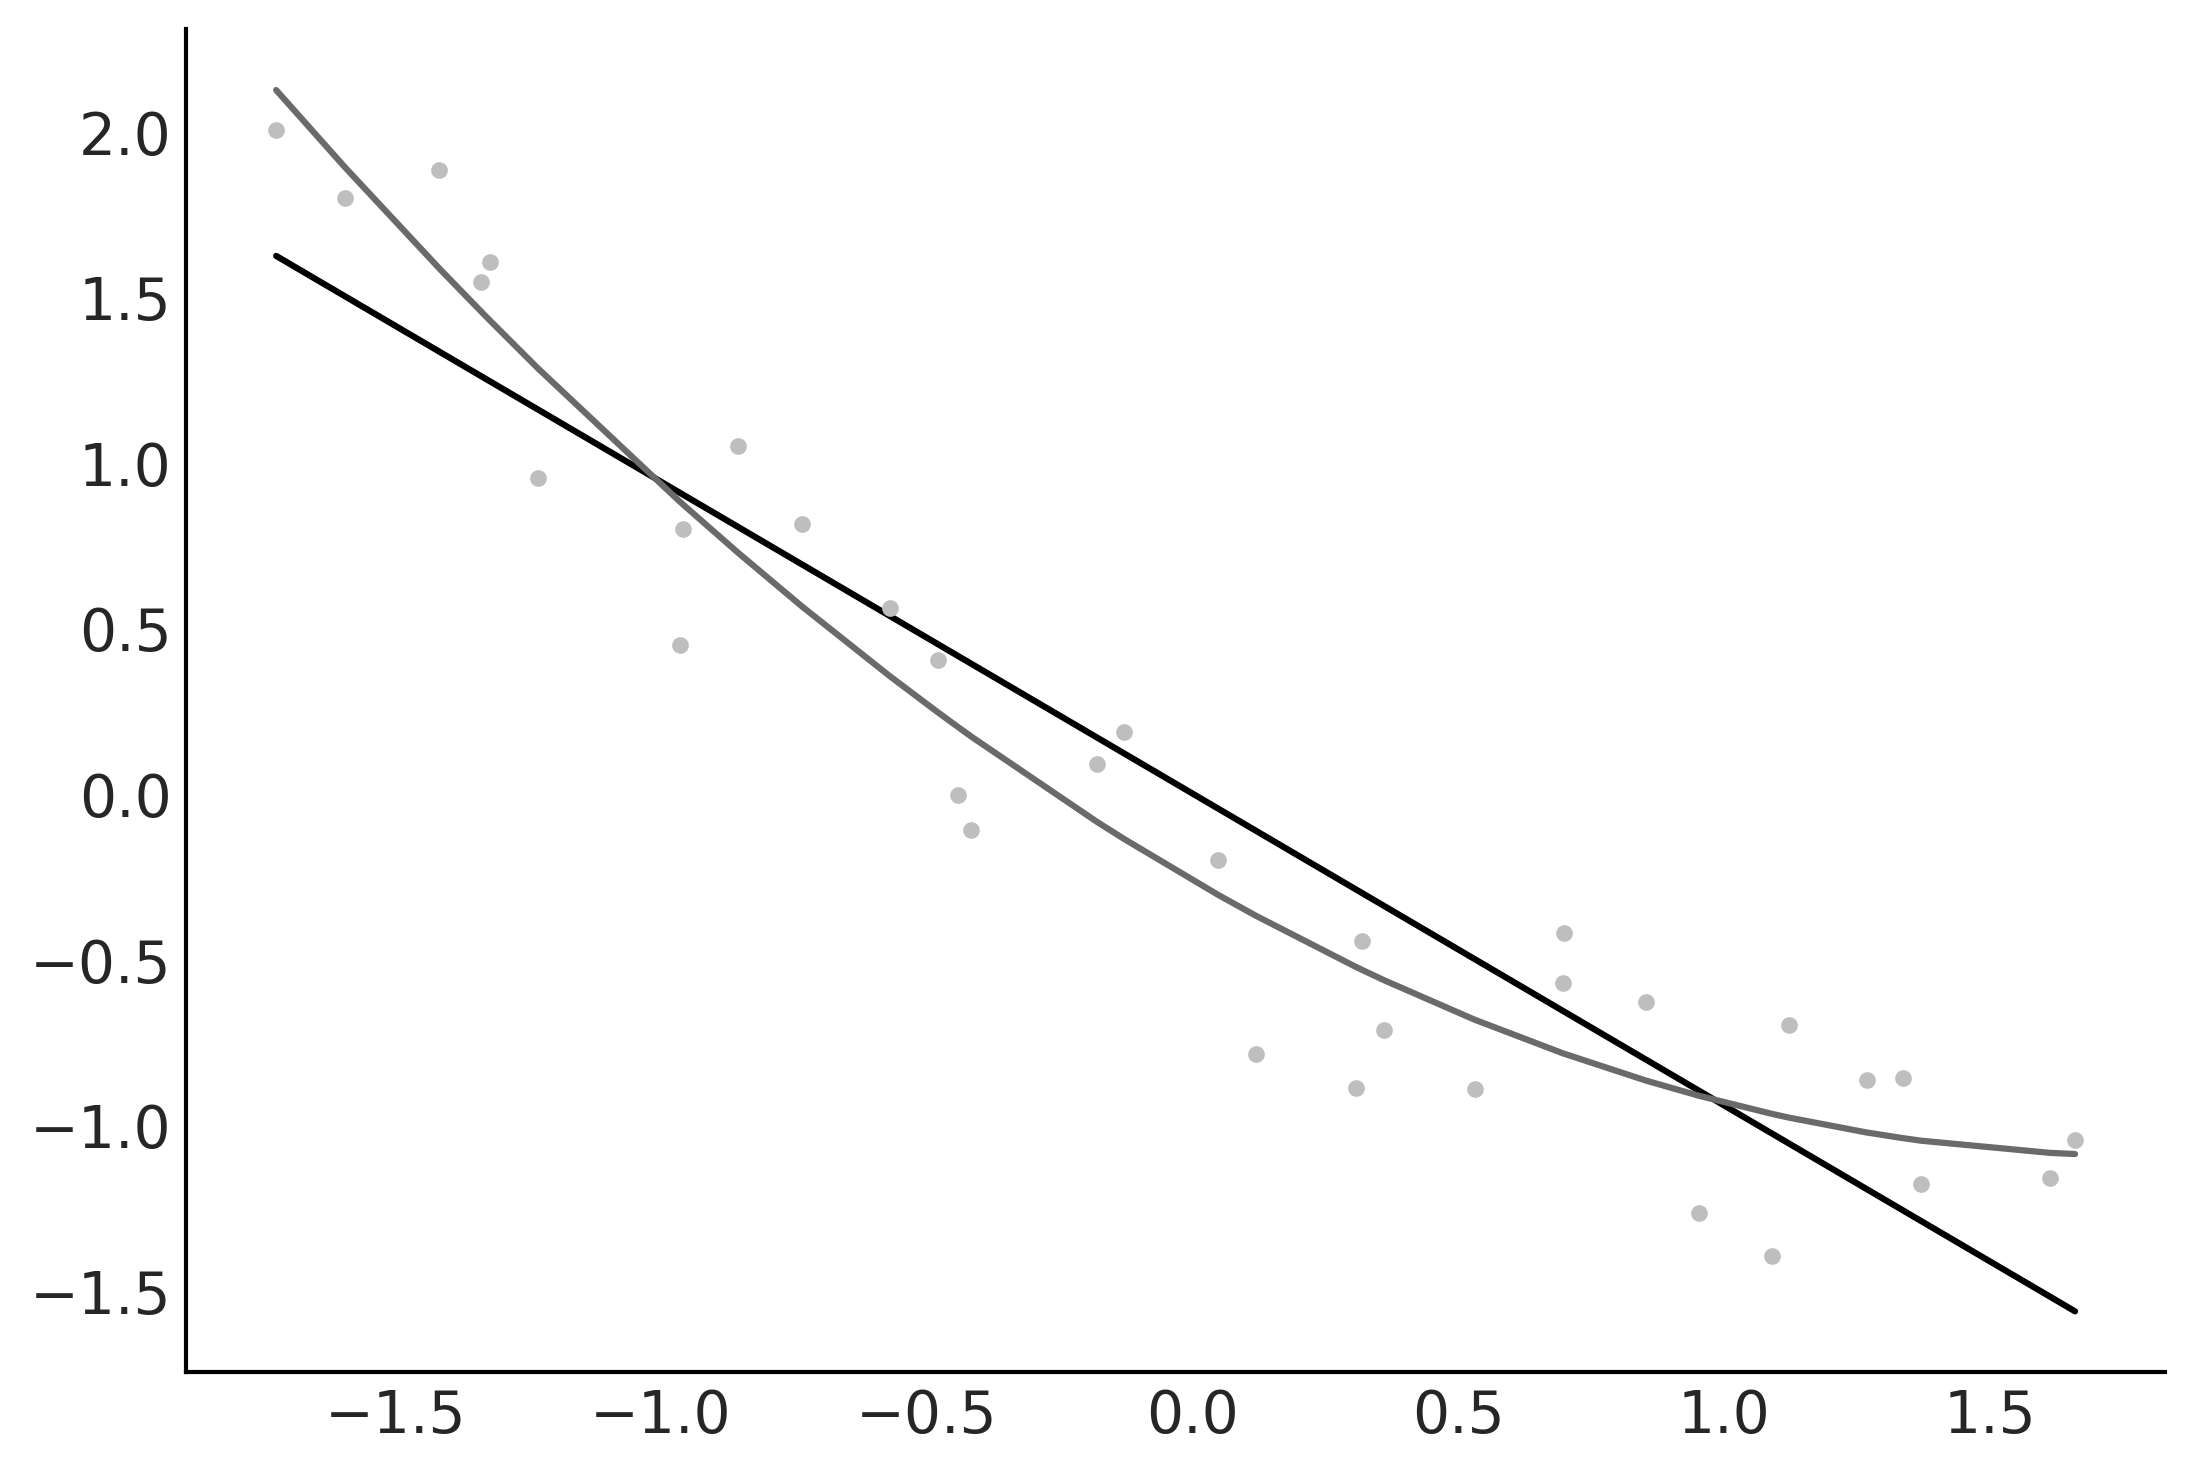

In [35]:
plt.plot(x_new, y_l_post, "C0", label="linear model")
plt.plot(x_c[0][idx], y_q_post[idx], "C1", label=f"quadratic model")
plt.plot(x_c[0], y_c, "C2.")

사후 예측 점검 (ppc)

array([<Axes: xlabel='y_pred / y_pred'>], dtype=object)

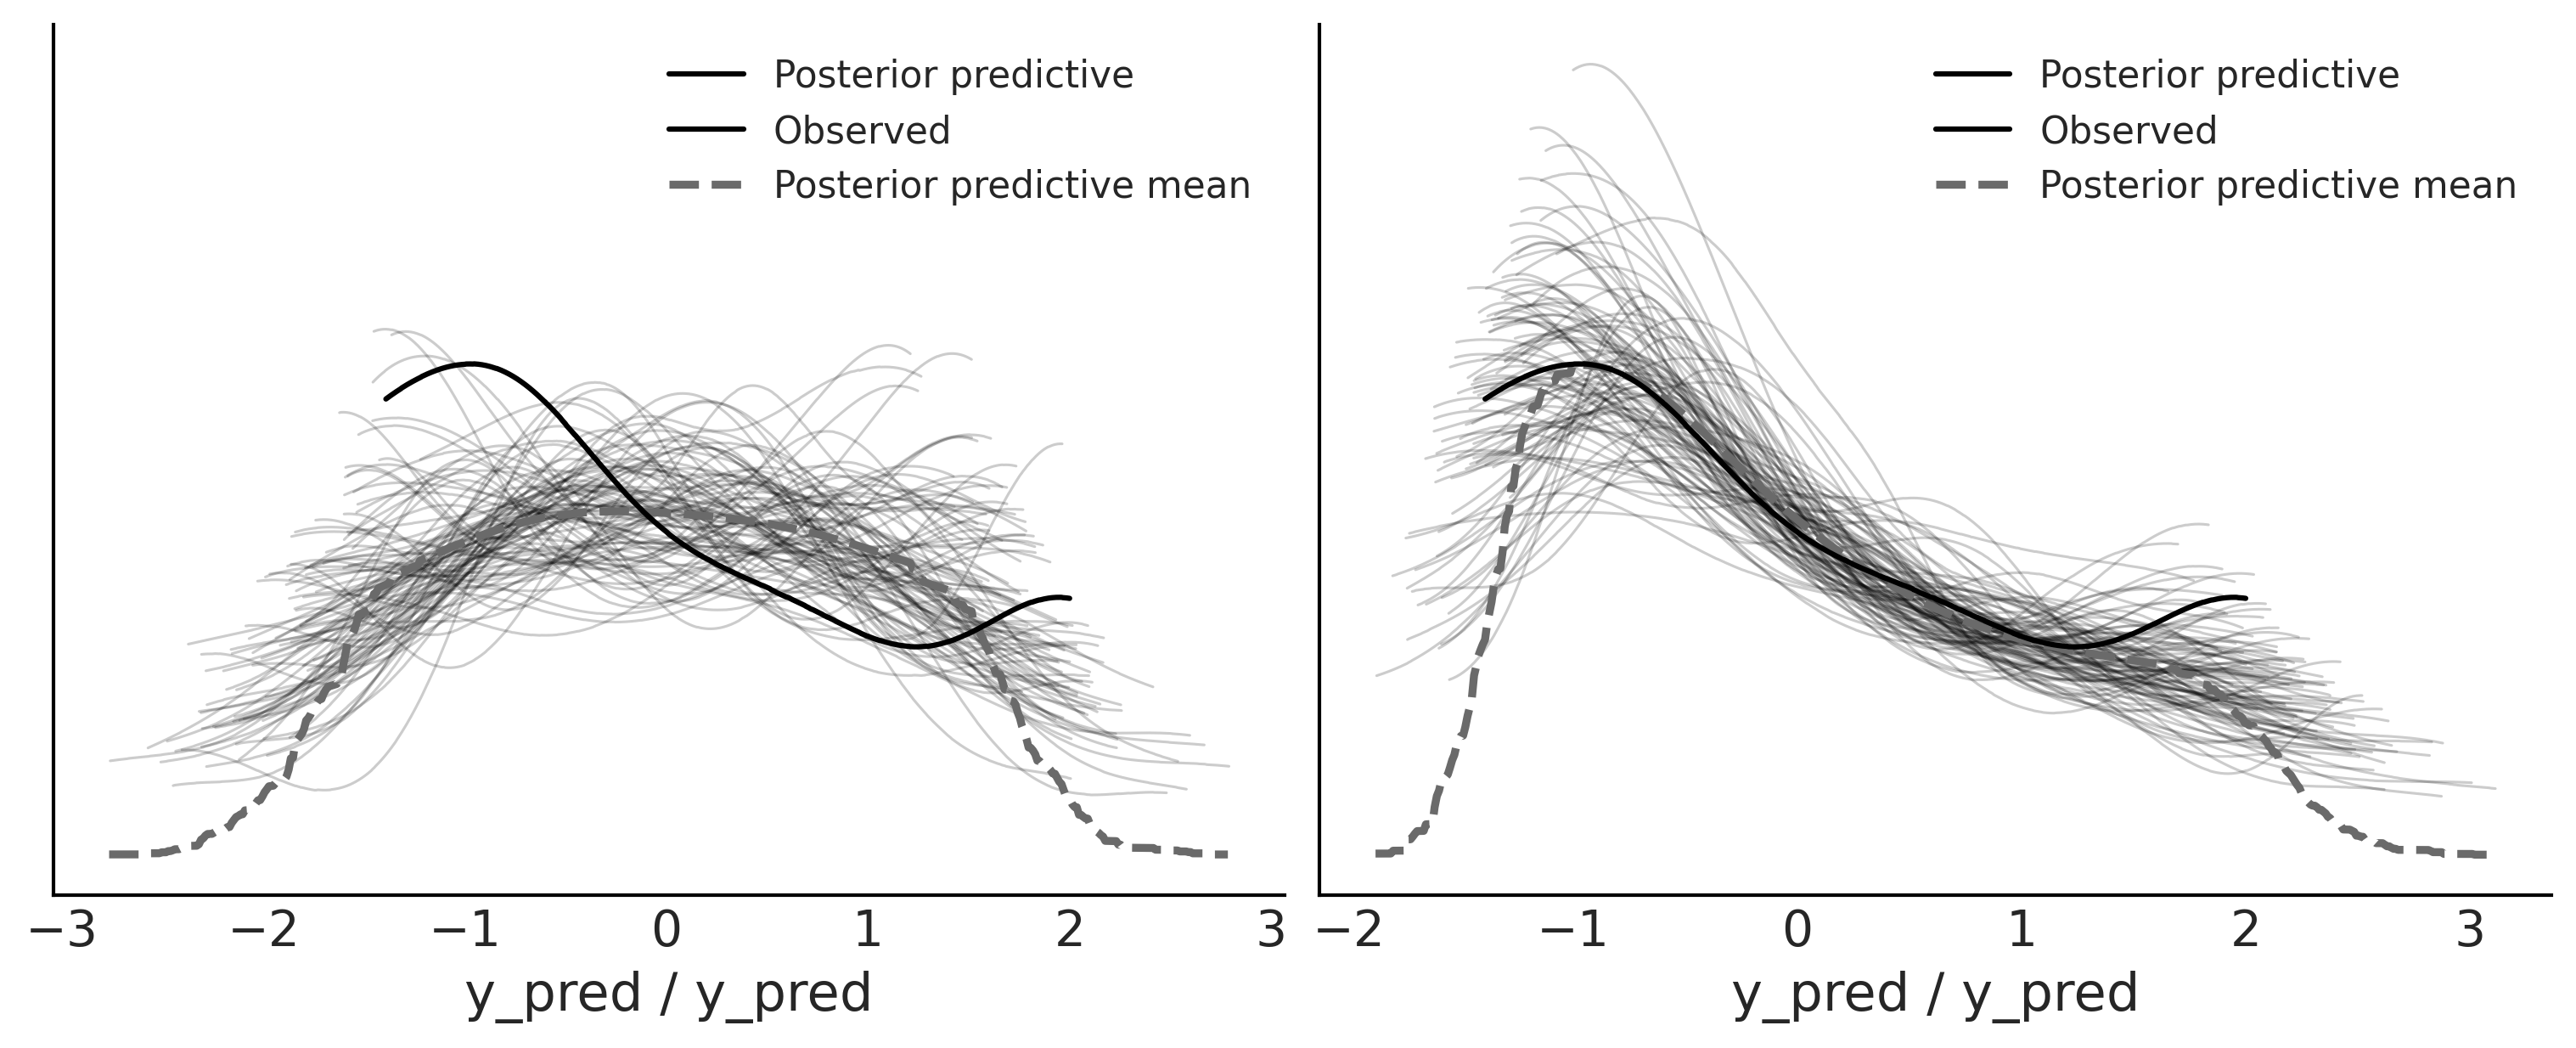

In [36]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
az.plot_ppc(idata_l, num_pp_samples=100, ax=axes[0])
az.plot_ppc(idata_q, num_pp_samples=100, ax=axes[1])

bayesian p-value

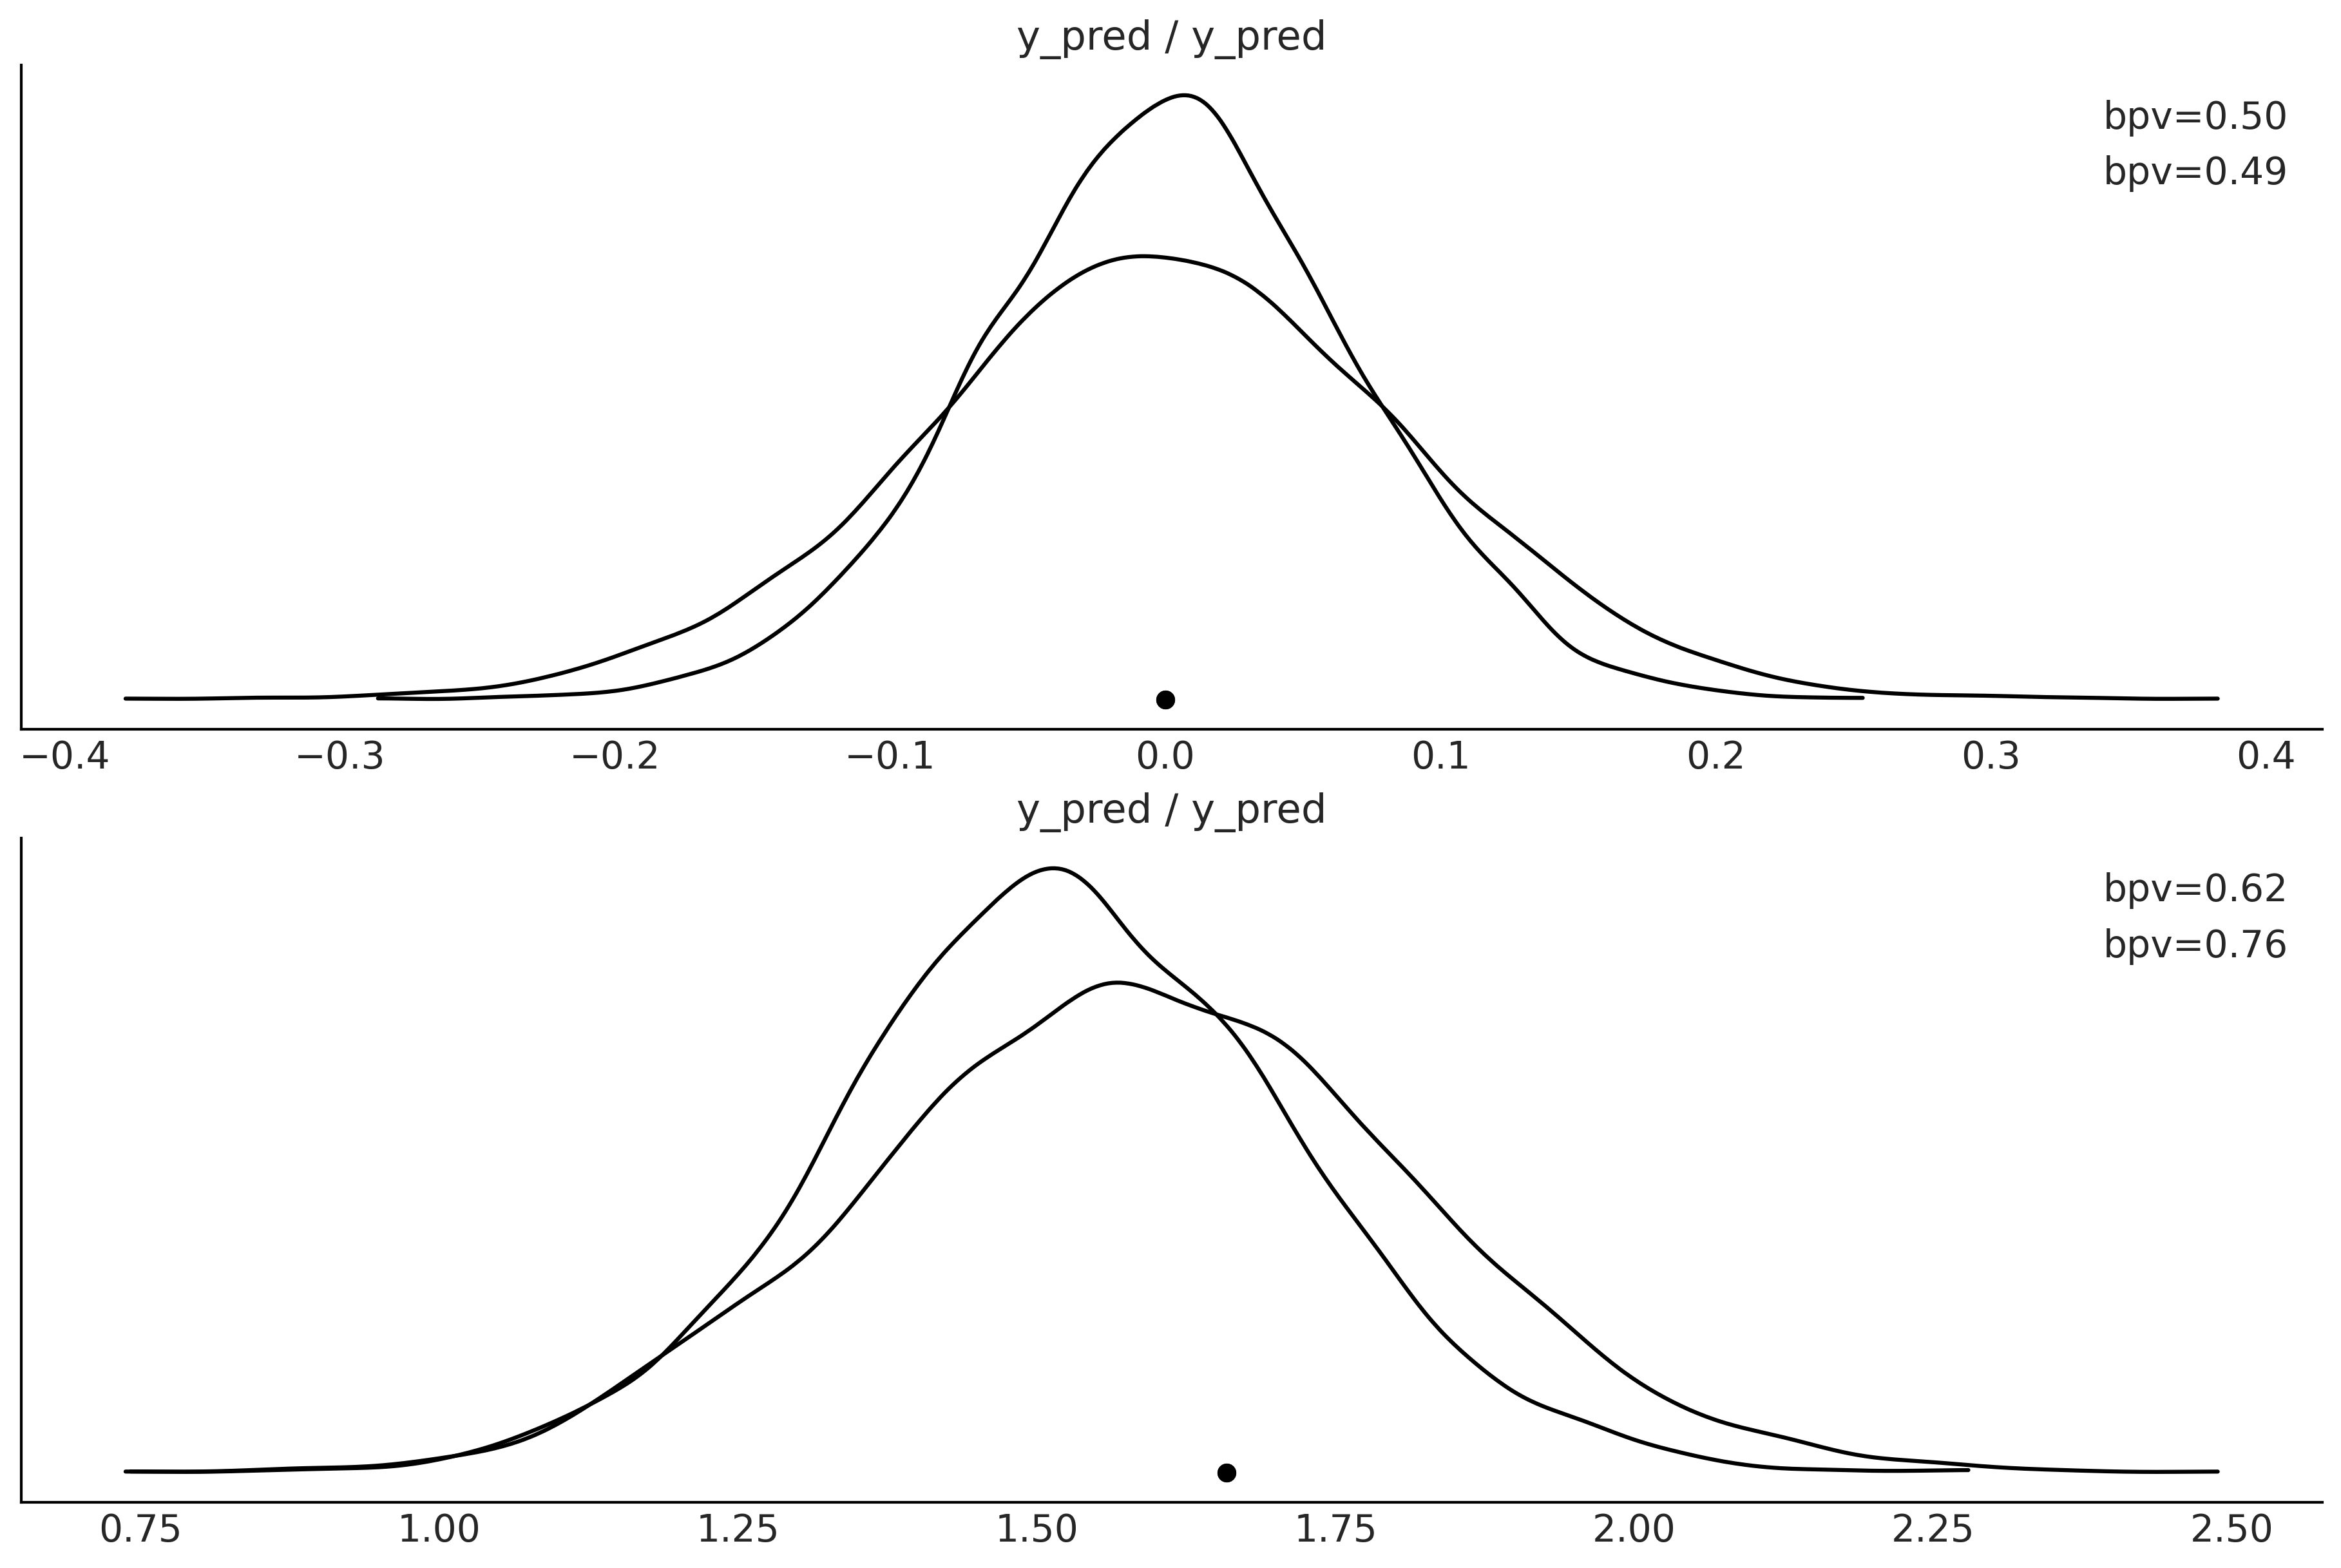

In [37]:
idatas = [idata_l, idata_q]

def iqr(x, a=-1):
    return np.subtract(*np.percentile(x, [75, 25], axis=a))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey="row")

for idata in idatas:
    az.plot_bpv(idata, kind='t_stat', t_stat="mean", ax=axes[0])

for idata in idatas:
    az.plot_bpv(idata, kind='t_stat', t_stat=iqr, ax=axes[1])

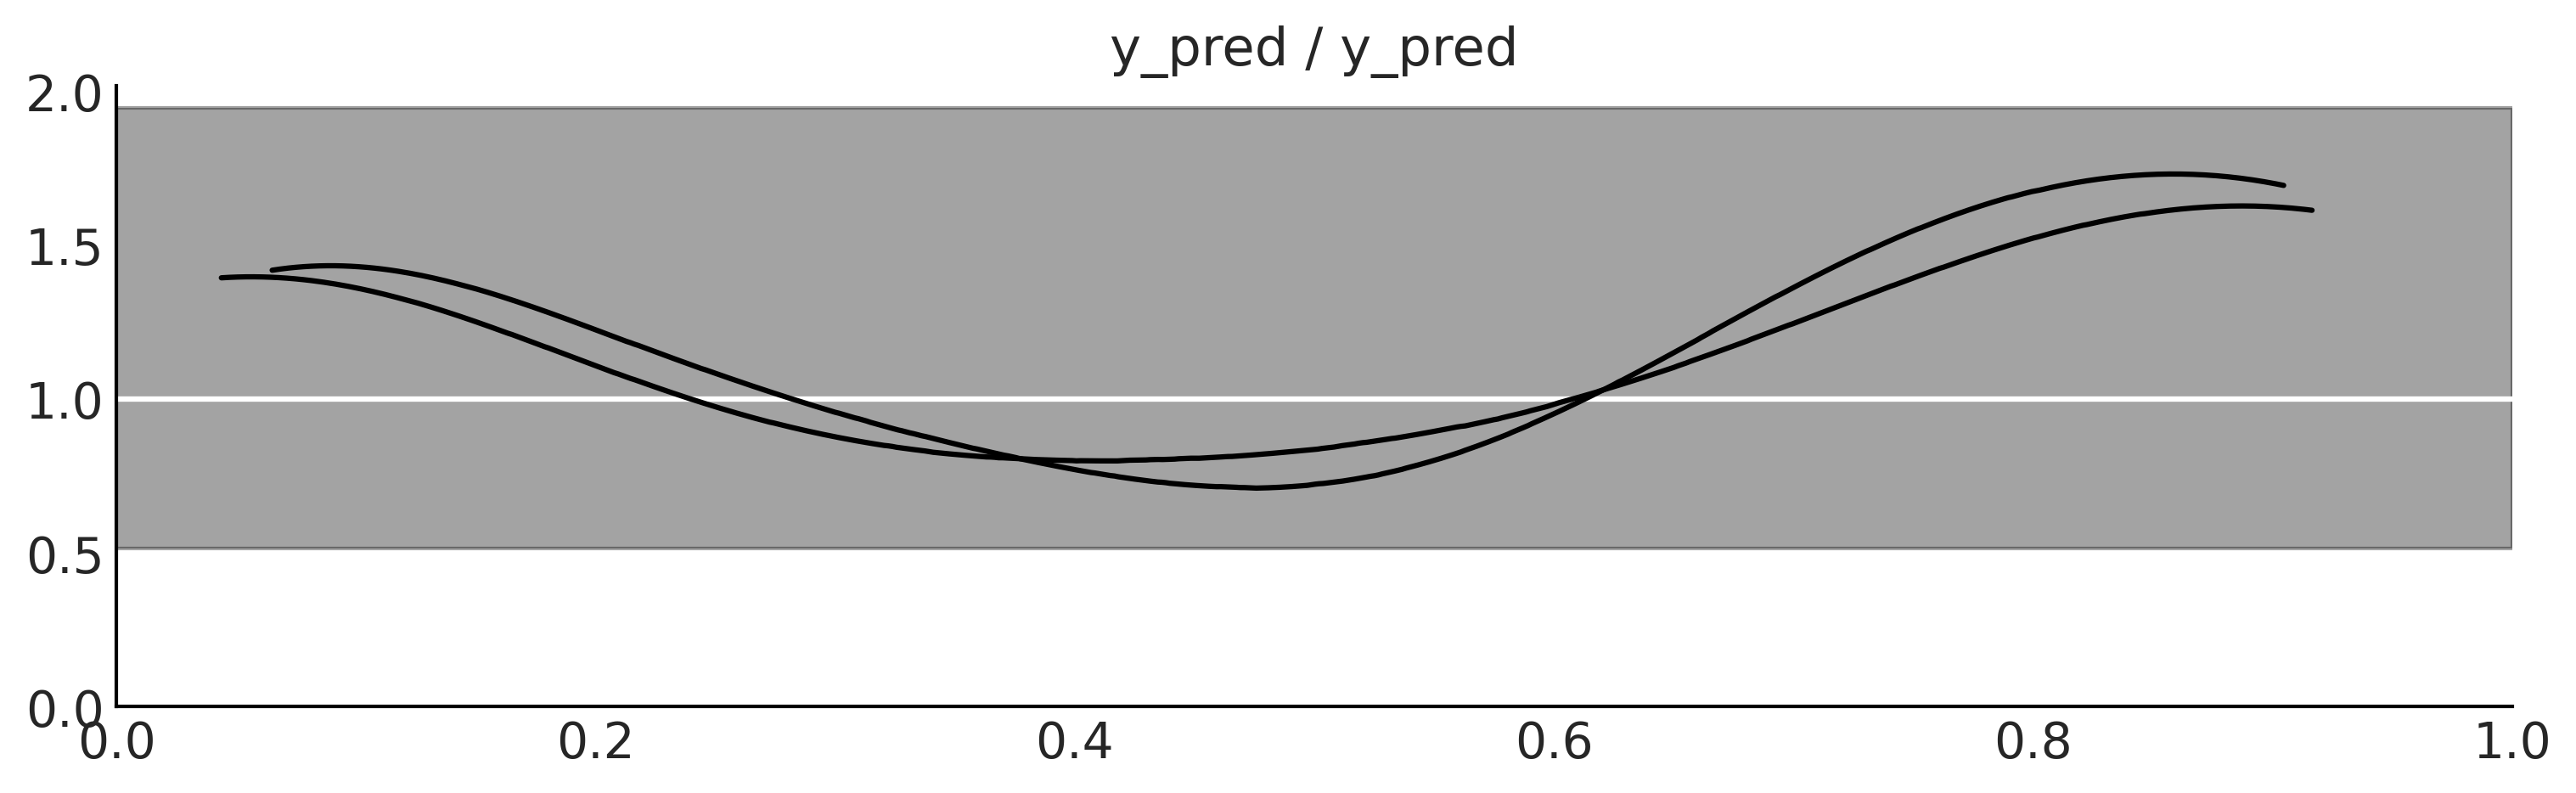

In [38]:
fig, ax = plt.subplots(figsize=(10, 3))

for idata in idatas:
    az.plot_bpv(idata, ax=ax)

WAIC와 LOO 계산

In [39]:
az.loo(idata_l)

Computed from 8000 posterior samples and 33 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -14.28     2.65
p_loo        2.37        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       33  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [40]:
az.waic(idata_l)

Computed from 8000 posterior samples and 33 observations log-likelihood matrix.

          Estimate       SE
elpd_waic   -14.26     2.65
p_waic        2.35        -

In [42]:
cmp_df = az.compare({"model_l": idata_l, "model_q": idata_q})
cmp_df

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:307: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'log' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_q,0,-4.523733,2.615623,0.000000,1.0,2.343613,0.000000,False,log
model_l,1,-14.283158,2.374816,9.759425,0.0,2.651583,2.646896,False,log


/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/compareplot.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale = comp_df["scale"][0]


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

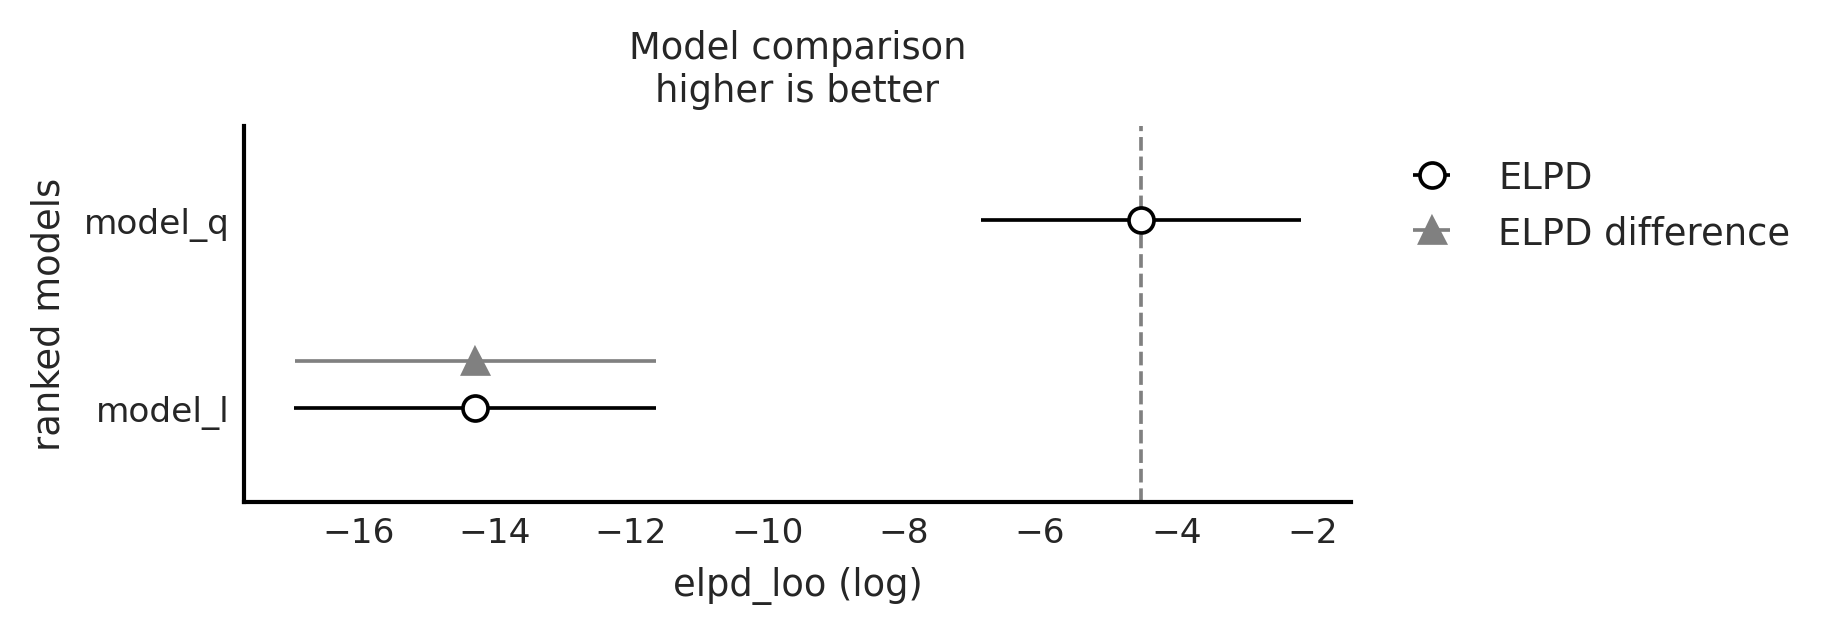

In [43]:
az.plot_compare(cmp_df)

In [45]:
idata_w = az.weight_predictions(idatas, weights=[0.35, 0.65])
idata_w

Inference data with groups:
	> posterior_predictive
	> observed_data

<Axes: >

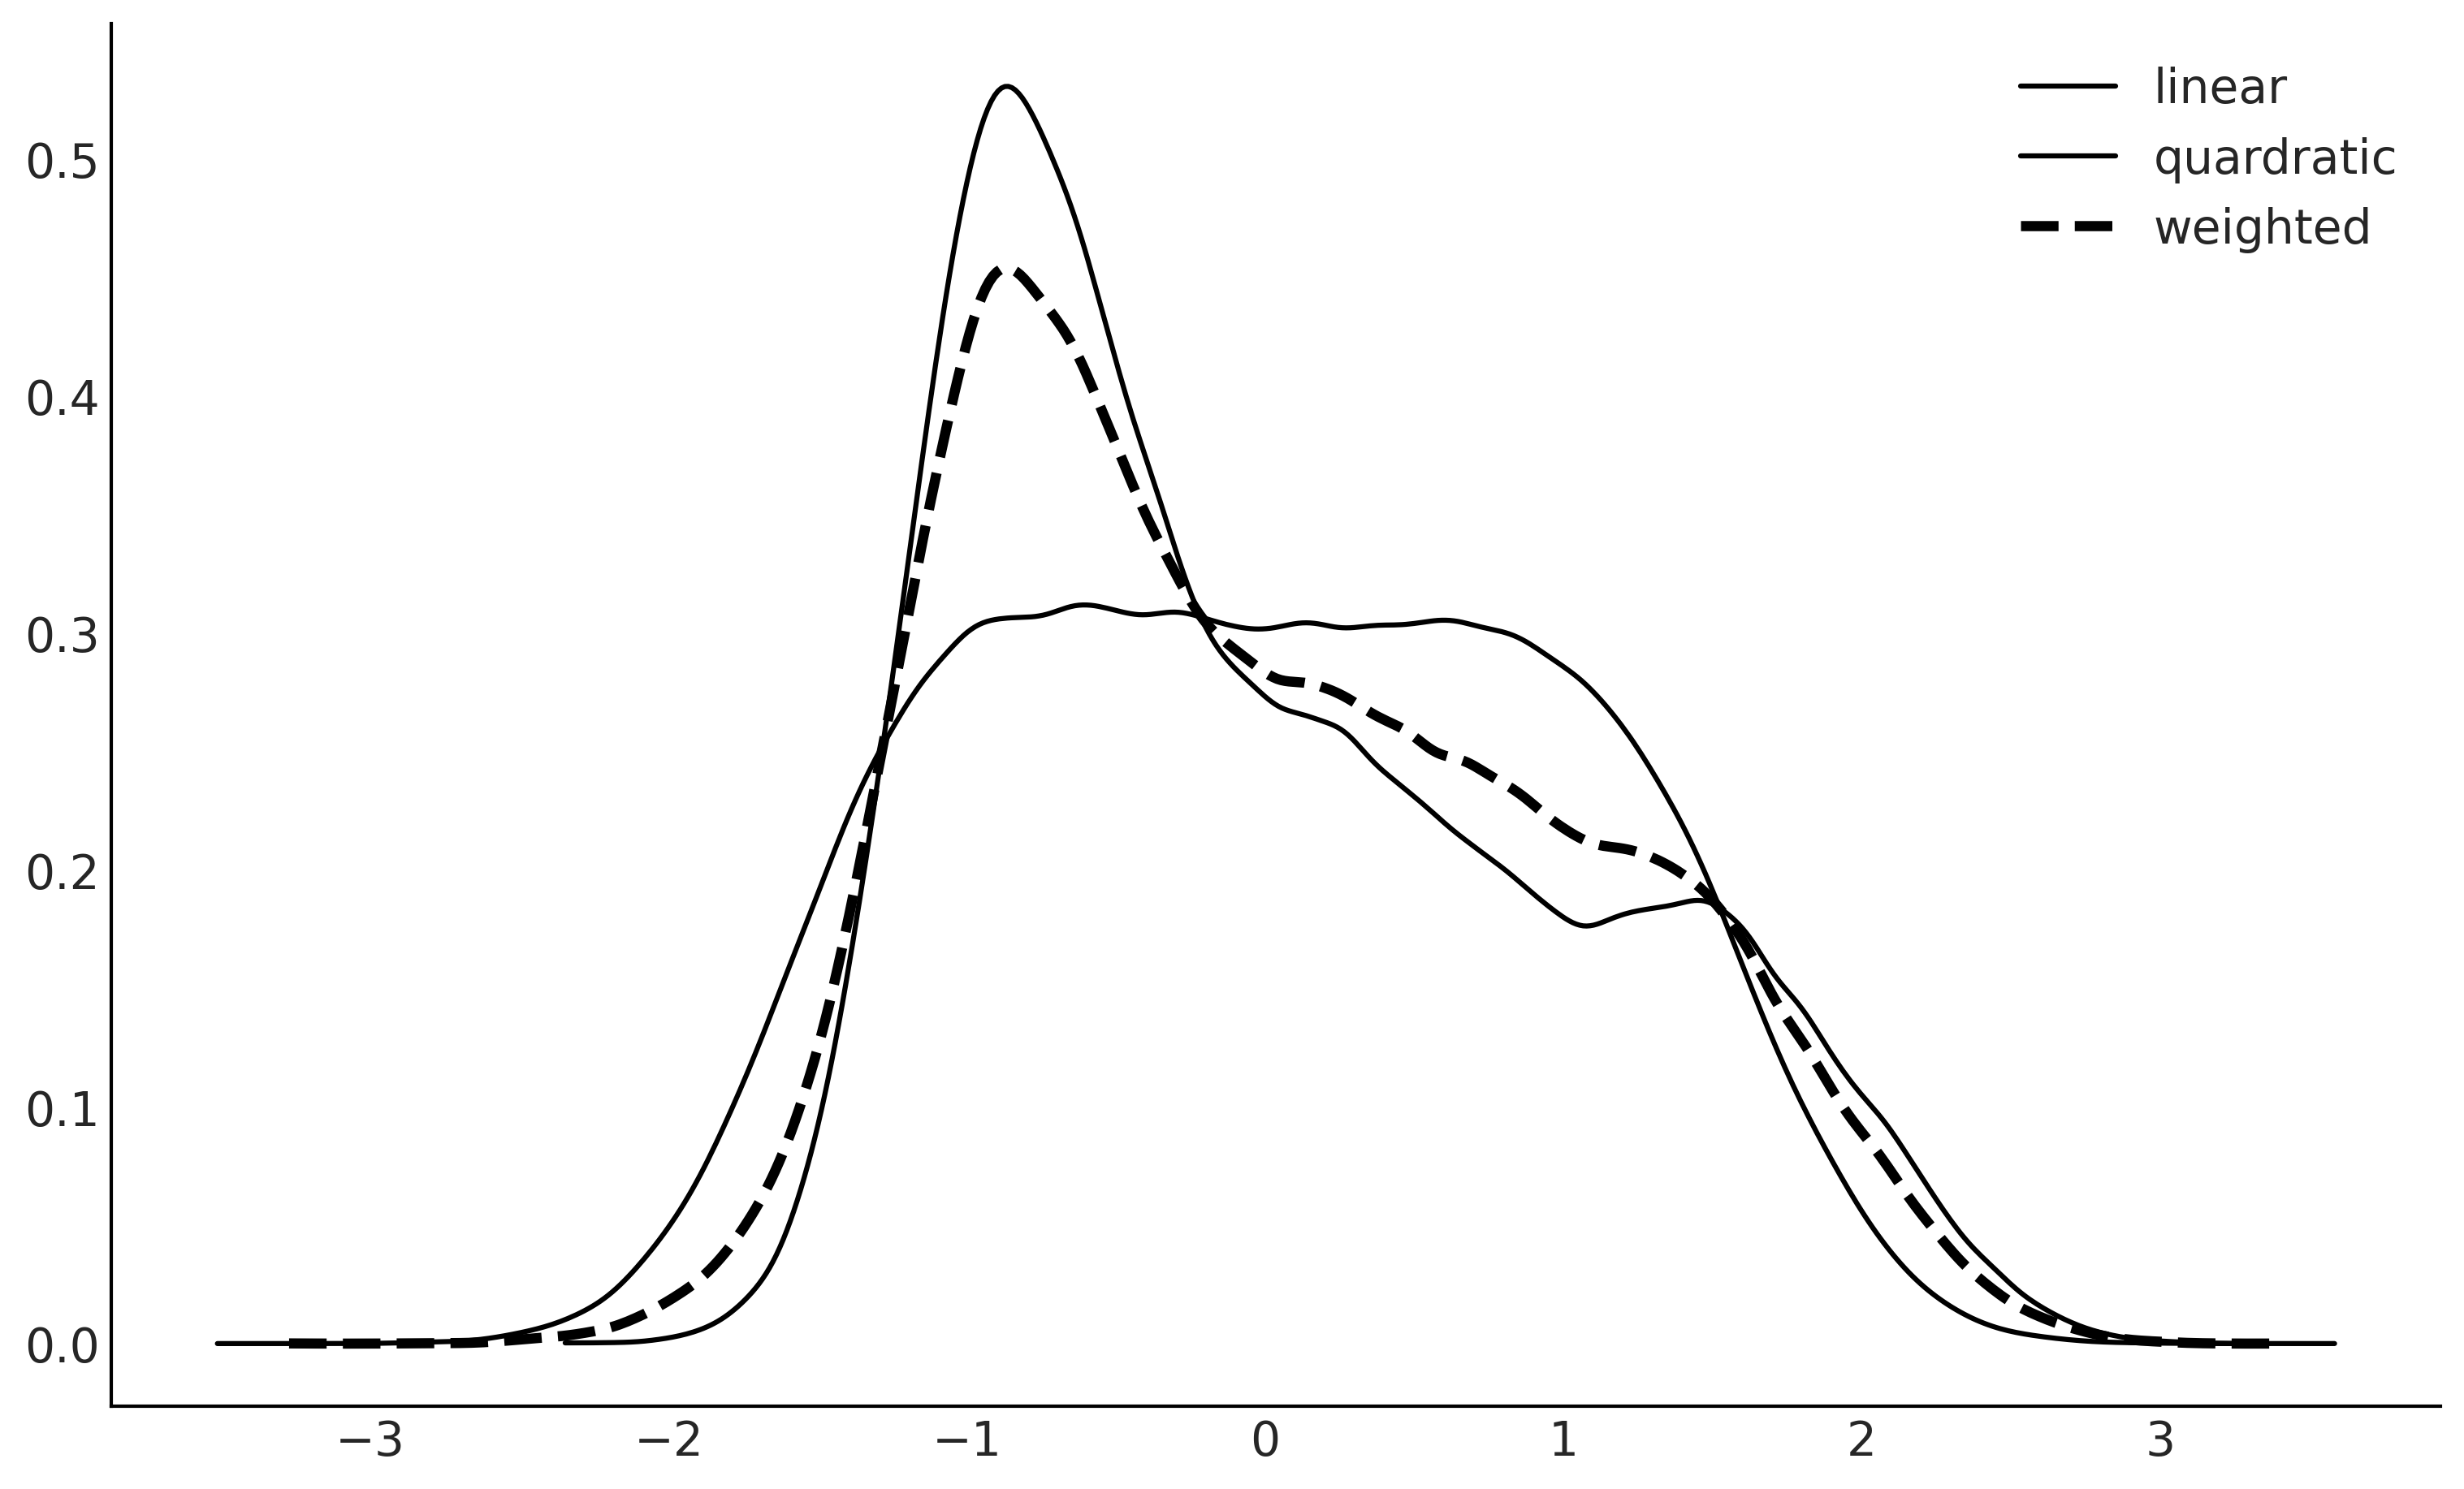

In [48]:
_, ax = plt.subplots(figsize=(10, 6))
az.plot_kde(idata_l.posterior_predictive['y_pred'].values,
            label='linear', ax=ax)

az.plot_kde(idata_q.posterior_predictive['y_pred'].values,
            label='quardratic', ax=ax)

az.plot_kde(idata_w.posterior_predictive['y_pred'].values,
            label='weighted', ax=ax, 
            plot_kwargs={'lw': 3, "ls": "--"})

Bayes factor

In [50]:
y = np.repeat([1, 0], [50, 50]) # 50 head 50 tail
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [52]:
priors = ((1 , 1), (30, 30)) # uniform prior, peaked prior

In [55]:
from scipy.special import betaln

def beta_binom(prior, y):
    """
    Calculate the marginal probability, analytically, for a BetaBinomial model.
    prior : tuple
        alpha and beta parameters for the beta prior
    y : array
        array with "1" and "0" corresponding to success and failure respectively
    """
    alpha, beta = prior
    h = np.sum(y)
    n = len(y)
    p_y = np.exp(betaln(alpha + h, beta + n - h) - betaln(alpha, beta))
    return p_y

In [57]:
BF = beta_binom(priors[1], y) / beta_binom(priors[0], y)
print(BF)

4.909762168061367


In [54]:
models = []
idatas = []
for alpha, beta in priors:
    with pm.Model() as model:
        a = pm.Beta('a', alpha, beta)
        yl = pm.Bernoulli("yl", a, observed=y)
        idata = pm.sample_smc(random_seed=123)
        models.append(model)
        idatas.append(idata)

BF_smc = np.exp(
    idatas[1].sample_stats["log_marginal_likelihood"].mean()
     - idatas[0].sample_stats["log_marginal_likelihood"].mean()
)

BF_smc


Initializing SMC sampler...
Sampling 8 chains in 8 jobs


/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/data/base.py:221: UserWarning: More chains (8) than draws (3). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
Initializing SMC sampler...
Sampling 8 chains in 8 jobs


/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/data/base.py:221: UserWarning: More chains (8) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


<xarray.DataArray 'log_marginal_likelihood' ()>
array(4.9171297)

In [58]:
with pm.Model() as model_uni:
    a = pm.Beta("a", 1, 1)
    yl = pm.Bernoulli("yl", a, observed=y)
    idata_uni = pm.sample(2000, random_seed=42)
    idata_uni.extend(pm.sample_prior_predictive(8000))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.
Sampling: [a, yl]


({'BF10': 0.1260324621685993, 'BF01': 7.934463730957305},
 <Axes: title={'center': 'The BF_10 is 0.13\nThe BF_01 is 7.93'}, xlabel='a', ylabel='Density'>)

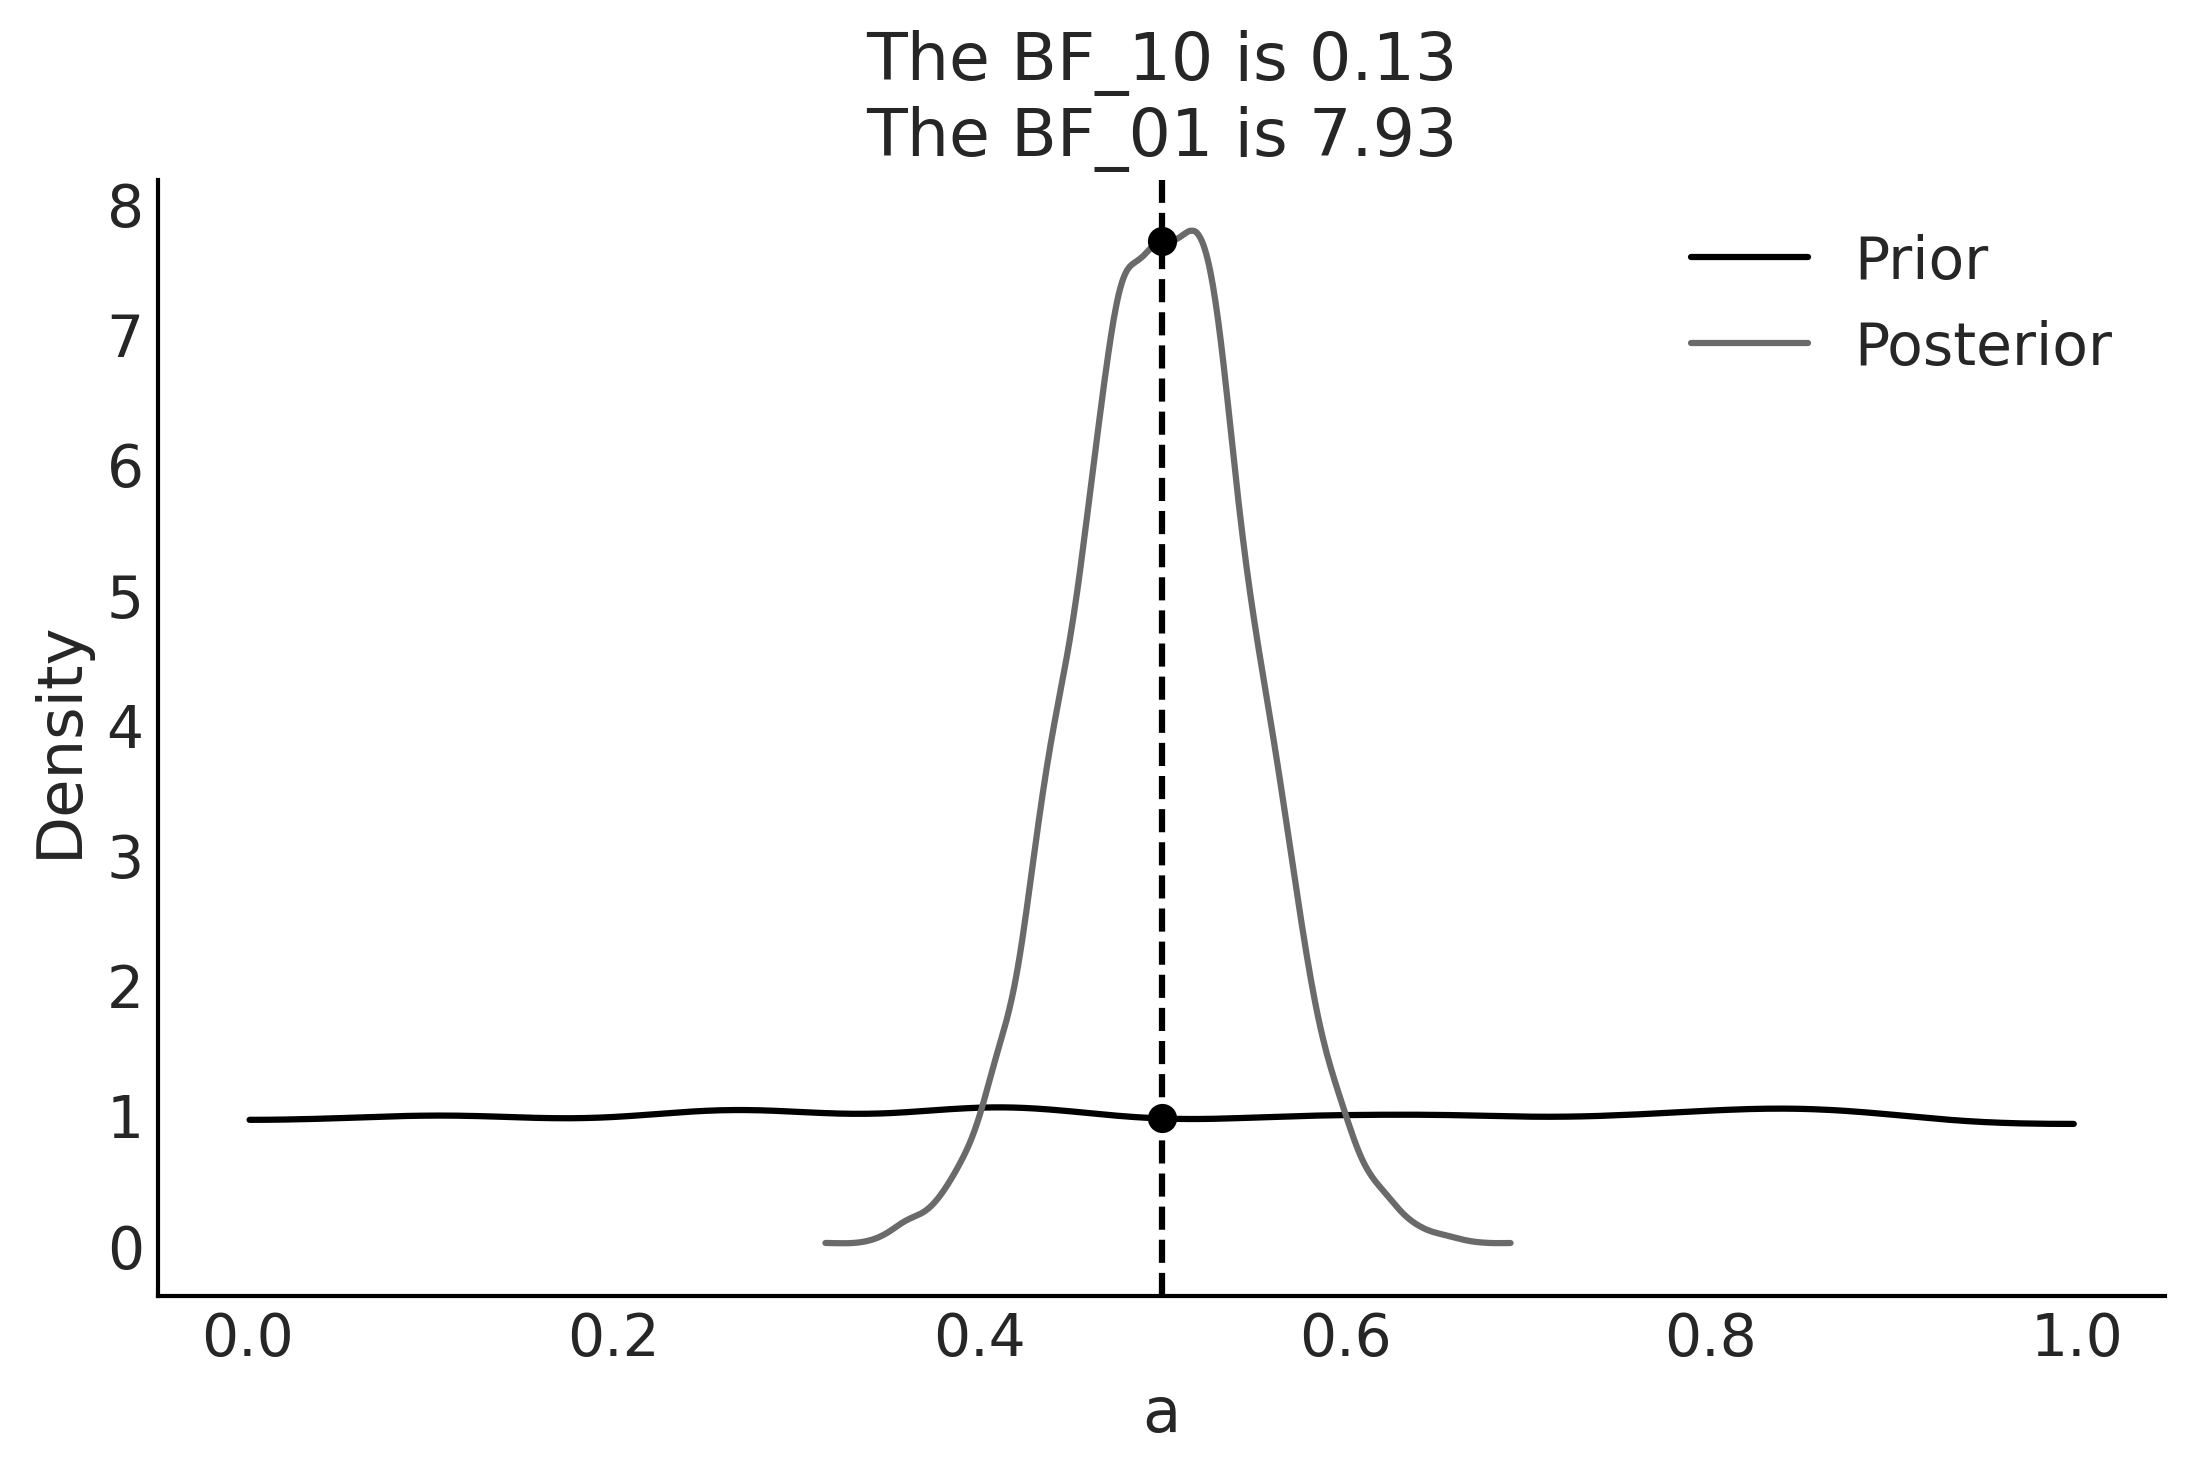

In [59]:
az.plot_bf(idata_uni, var_name='a', ref_val=0.5)

In [60]:
with pm.Model() as model_conc:
    a = pm.Beta('a', 30, 30)
    yl = pm.Bernoulli('yl', a, observed=y)
    idata_conc = pm.sample(2000, random_seed=42)
    idata_conc.extend(pm.sample_prior_predictive(8000))


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.
Sampling: [a, yl]


({'BF10': 0.5904548576587083, 'BF01': 1.6936095740921397},
 <Axes: title={'center': 'The BF_10 is 0.59\nThe BF_01 is 1.69'}, xlabel='a', ylabel='Density'>)

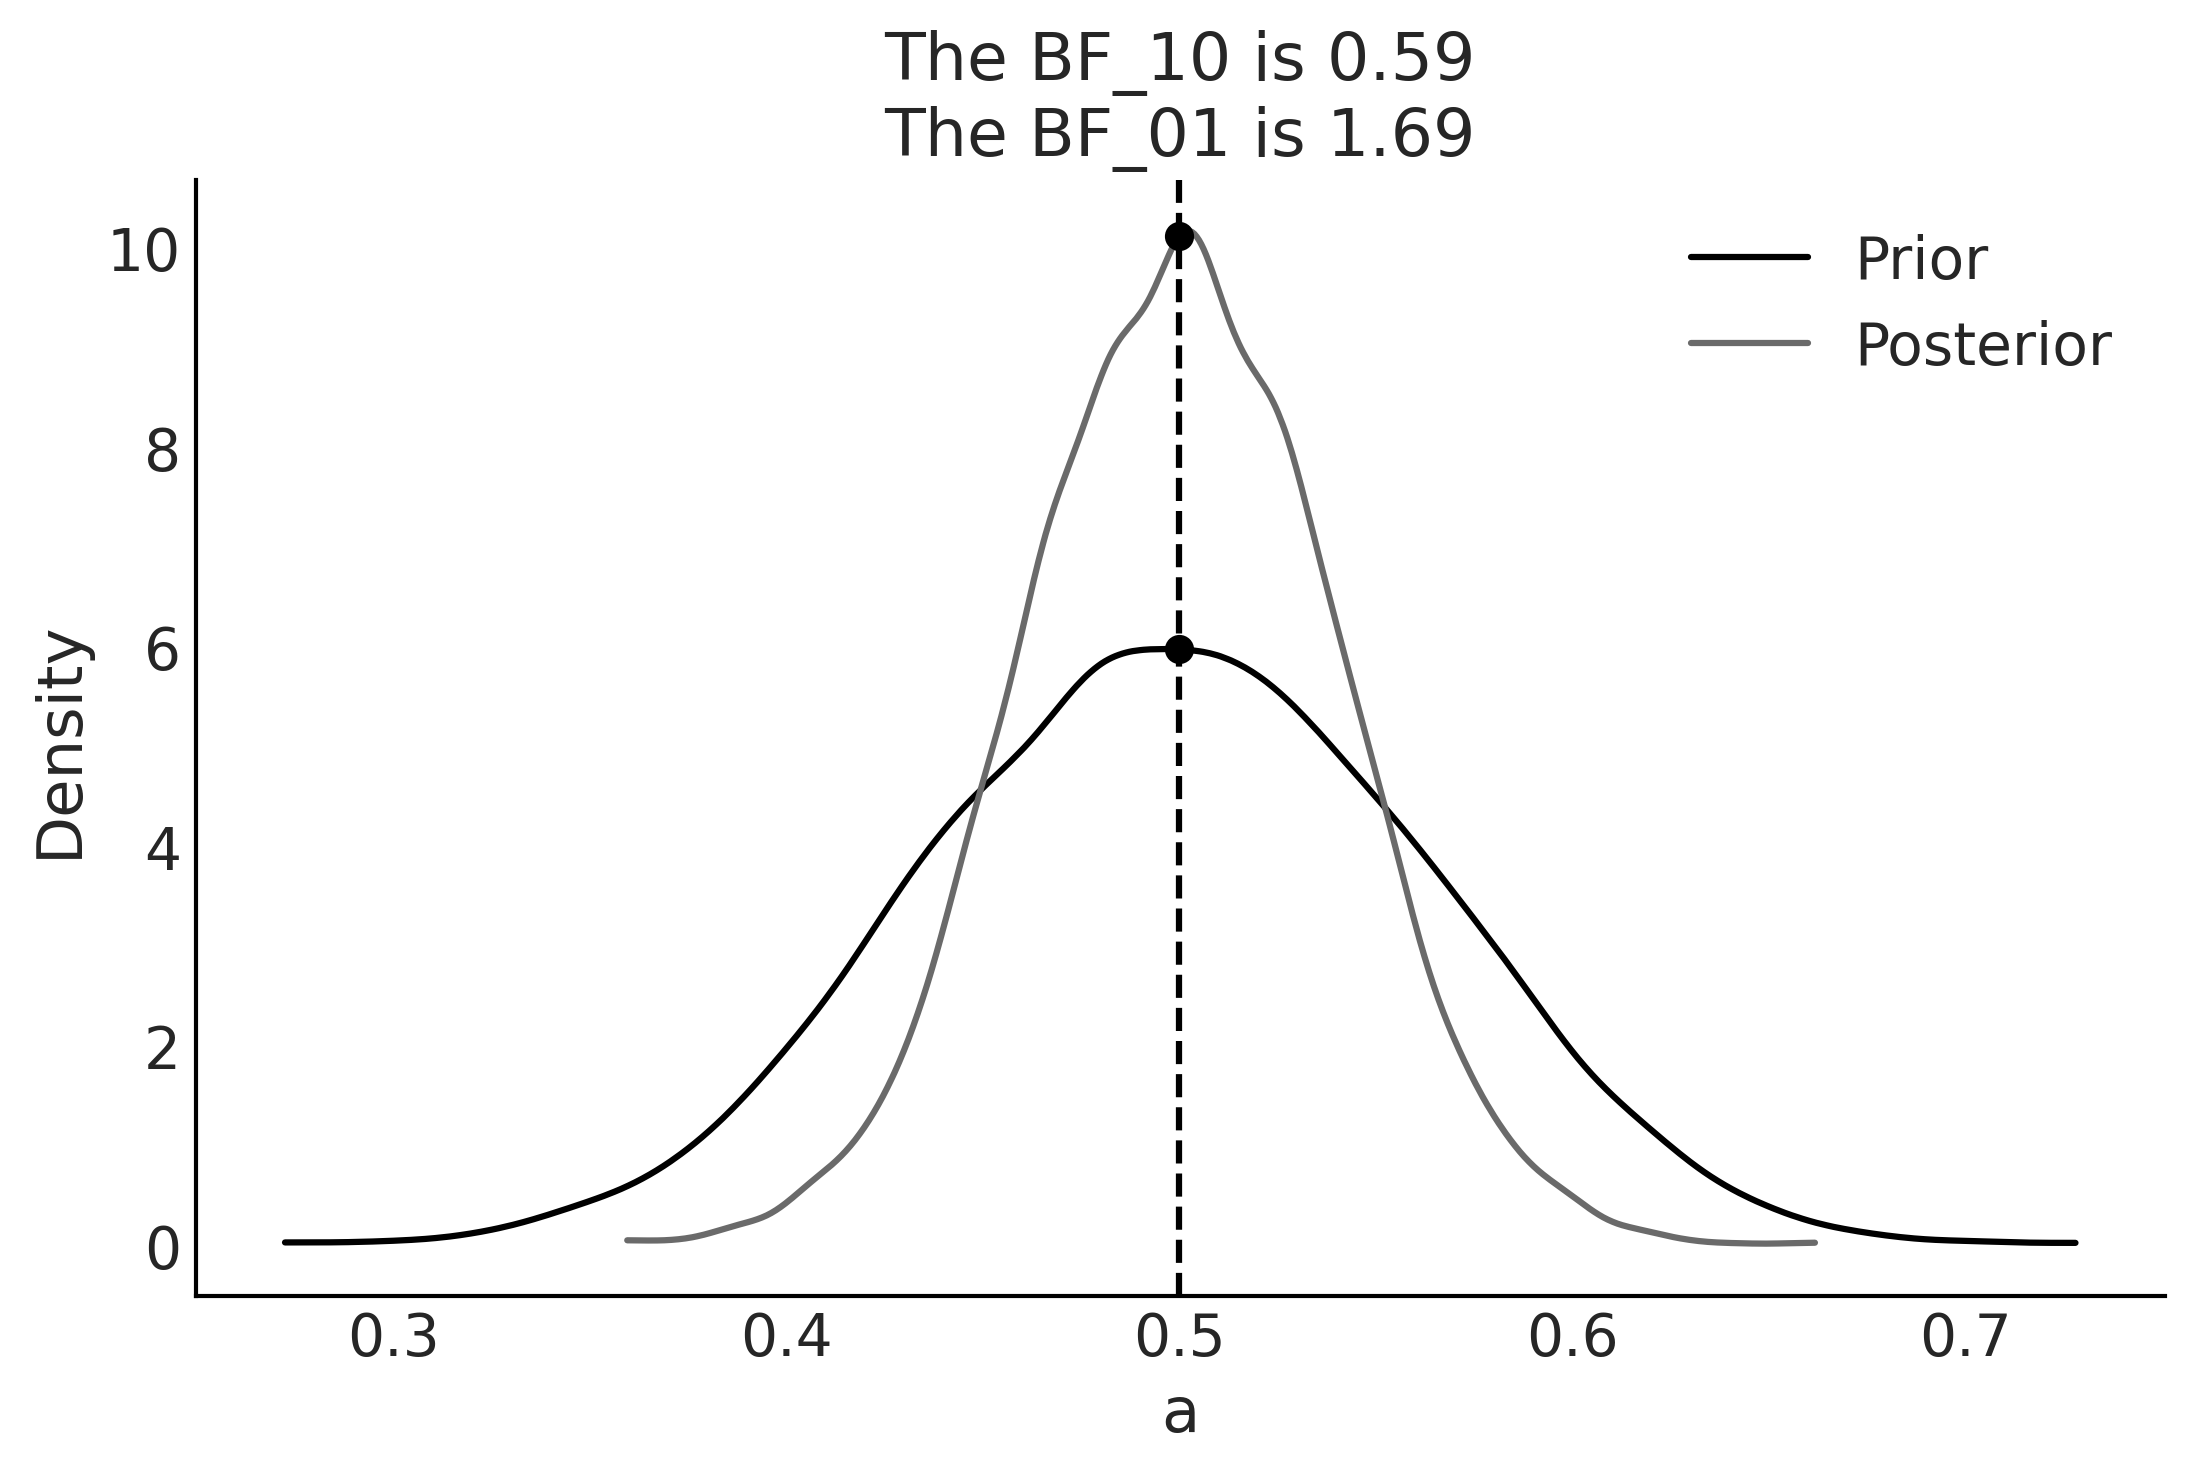

In [61]:
az.plot_bf(idata_conc, var_name='a', ref_val=0.5)

In [64]:
df0 = az.summary(idata_uni)
df1 = az.summary(idata_conc)
pd.concat([df0, df1], axis=0).set_index([["uniform", "peaked"]])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
uniform,0.501,0.049,0.404,0.587,0.001,0.001,3654.0,5523.0,1.0
peaked,0.500,0.039,0.428,0.575,0.001,0.000,3832.0,5284.0,1.0


<Axes: >

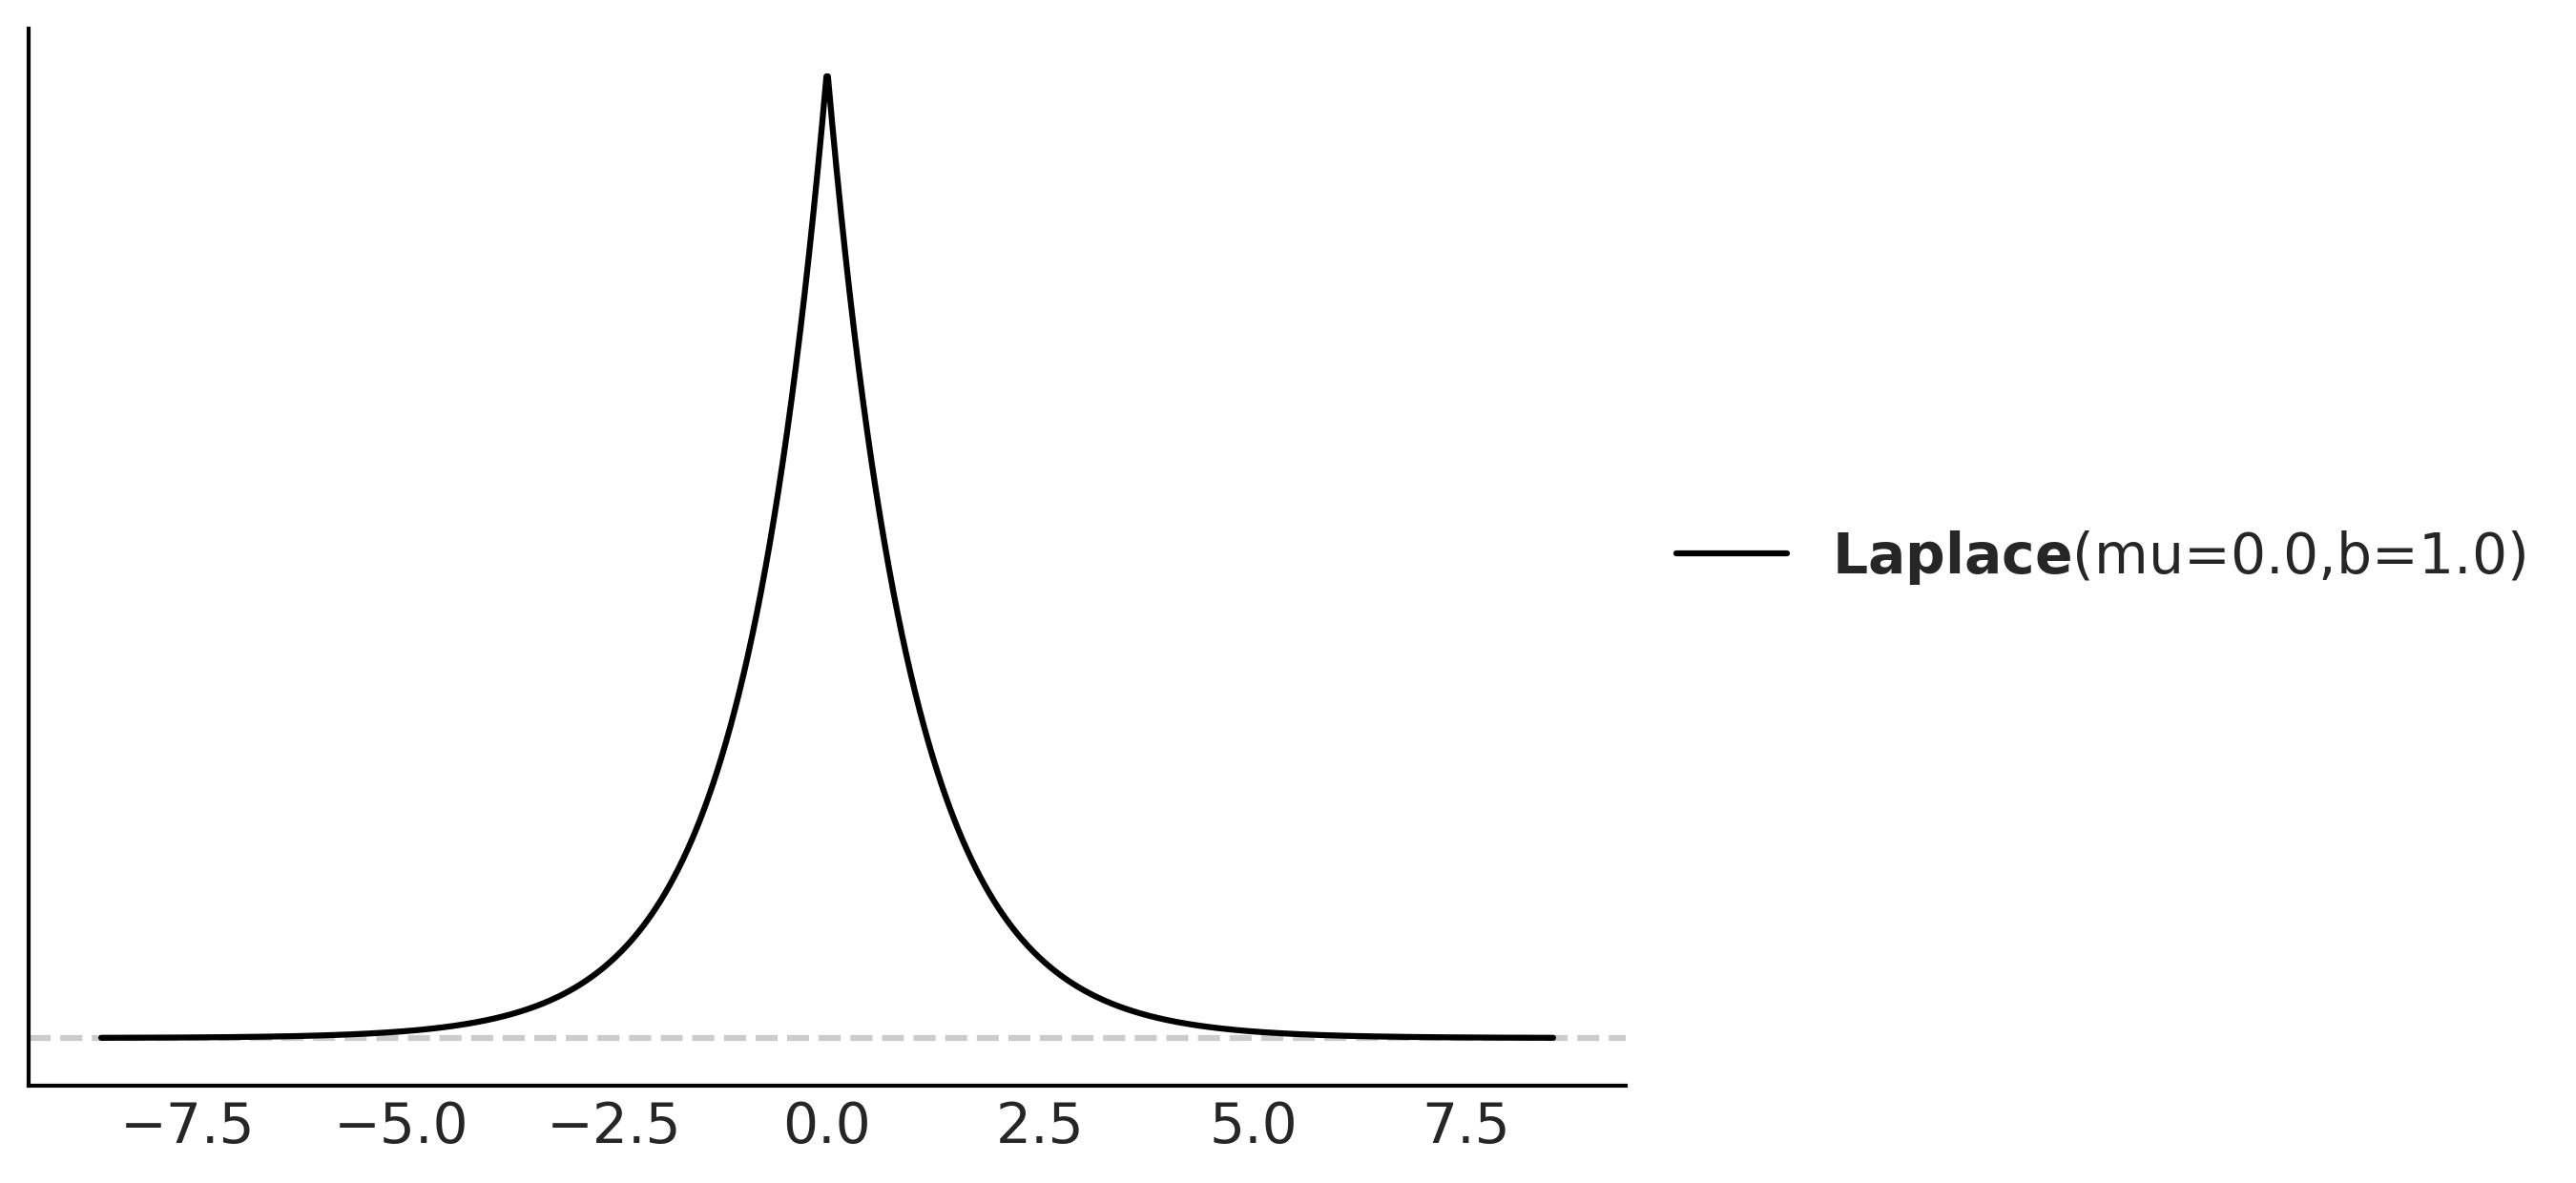

In [65]:
pz.Laplace(0, 1).plot_pdf()